# Chapter 10: Statistics for Business Decisions

**Goal**: Use descriptive statistics and basic distributions to understand data and support decisions.

Aligned with the Machine Learning section of the original tutorial (Mean, Median, Mode, Std Dev, Percentile, Distributions).

---

## 11.1 Measures of Central Tendency

In [1]:
import numpy as np
import pandas as pd
from scipy import stats

sales = np.array([98, 105, 112, 98, 125, 130, 145, 112, 98, 160, 135, 118])

print("Mean   :", np.mean(sales))
print("Median :", np.median(sales))
print("Mode   :", stats.mode(sales, keepdims=True).mode[0])

Mean   : 119.66666666666667
Median : 115.0
Mode   : 98


**Business Insight**  
- Mean is sensitive to outliers (e.g., one huge deal).  
- Median is more robust for skewed data (common in income, sales, house prices).

---

## 11.2 Measures of Spread

In [2]:
print("Range        :", np.ptp(sales))
print("Variance     :", np.var(sales))
print("Std Deviation:", np.std(sales))
print("Coeff of Variation:", (np.std(sales) / np.mean(sales)) * 100, "%")

Range        : 62
Variance     : 365.2222222222222
Std Deviation: 19.110788110965547
Coeff of Variation: 15.970017920026919 %


---

## 11.3 Percentiles & Quartiles

In [3]:
print("25th percentile (Q1):", np.percentile(sales, 25))
print("50th percentile (Q2):", np.percentile(sales, 50))
print("75th percentile (Q3):", np.percentile(sales, 75))
print("90th percentile     :", np.percentile(sales, 90))

q1, q3 = np.percentile(sales, [25, 75])
iqr = q3 - q1
print("IQR:", iqr)

25th percentile (Q1): 103.25
50th percentile (Q2): 115.0
75th percentile (Q3): 131.25
90th percentile     : 144.0
IQR: 28.0


---

## 11.4 Normal Distribution – The Bell Curve

Many business metrics (customer lifetime value after transformation, process variations, test scores) approximate a normal distribution.

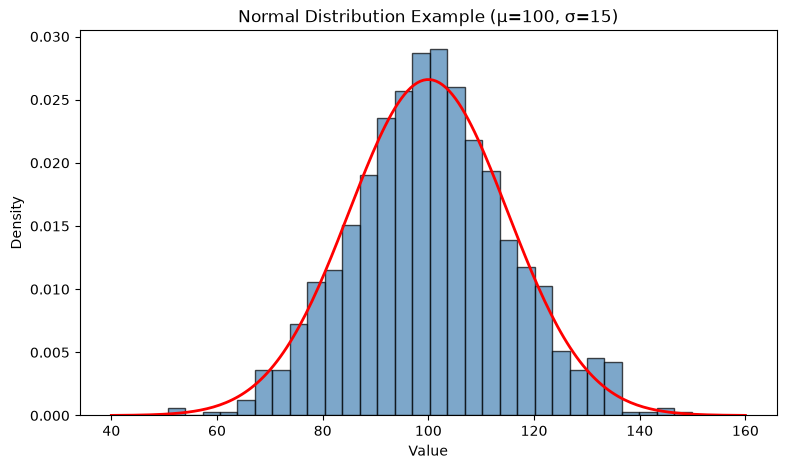

Approx % within 1σ: 69.89999999999999
Approx % within 2σ: 94.8


In [4]:
import matplotlib.pyplot as plt

mu = 100
sigma = 15
data = np.random.normal(mu, sigma, 1000)

plt.figure(figsize=(9, 5))
plt.hist(data, bins=30, density=True, alpha=0.7, color='steelblue', edgecolor='black')

# Overlay theoretical curve
x = np.linspace(mu - 4*sigma, mu + 4*sigma, 200)
plt.plot(x, stats.norm.pdf(x, mu, sigma), 'r-', linewidth=2)
plt.title("Normal Distribution Example (μ=100, σ=15)")
plt.xlabel("Value")
plt.ylabel("Density")
plt.show()

print("Approx % within 1σ:", np.mean((data > mu-sigma) & (data < mu+sigma)) * 100)
print("Approx % within 2σ:", np.mean((data > mu-2*sigma) & (data < mu+2*sigma)) * 100)

---

## 11.5 Correlation – Relationships Between Variables

Pearson Correlation: 0.999


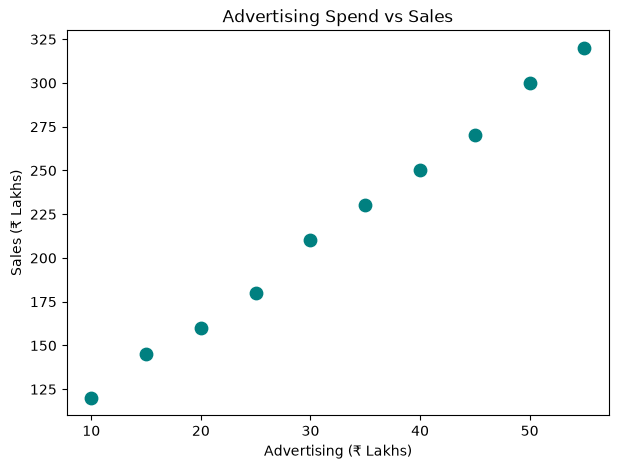

In [5]:
advertising = np.array([10, 15, 20, 25, 30, 35, 40, 45, 50, 55])
sales = np.array([120, 145, 160, 180, 210, 230, 250, 270, 300, 320])

corr = np.corrcoef(advertising, sales)[0, 1]
print(f"Pearson Correlation: {corr:.3f}")

plt.figure(figsize=(7, 5))
plt.scatter(advertising, sales, s=80, color='teal')
plt.title("Advertising Spend vs Sales")
plt.xlabel("Advertising (₹ Lakhs)")
plt.ylabel("Sales (₹ Lakhs)")
plt.show()

---

## 11.6 Business Application – Customer Purchase Analysis

Mean purchase   : 5912.0
Median purchase : 4953.0
90th percentile : 10597.0
% of customers > ₹10,000: 10.8 %


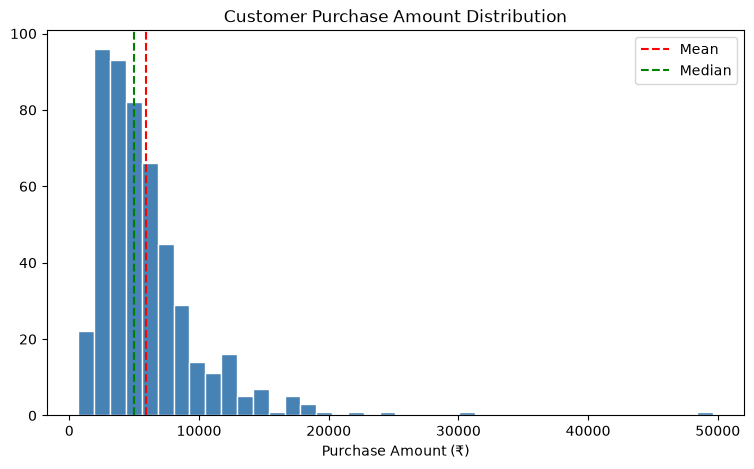

In [6]:
np.random.seed(42)
purchase_amount = np.random.lognormal(mean=8.5, sigma=0.6, size=500)  # Realistic skewed spend

print("Mean purchase   :", round(np.mean(purchase_amount), 0))
print("Median purchase :", round(np.median(purchase_amount), 0))
print("90th percentile :", round(np.percentile(purchase_amount, 90), 0))
print("% of customers > ₹10,000:", round(np.mean(purchase_amount > 10000)*100, 1), "%")

plt.figure(figsize=(9, 5))
plt.hist(purchase_amount, bins=40, color='steelblue', edgecolor='white')
plt.axvline(np.mean(purchase_amount), color='red', linestyle='--', label='Mean')
plt.axvline(np.median(purchase_amount), color='green', linestyle='--', label='Median')
plt.title("Customer Purchase Amount Distribution")
plt.xlabel("Purchase Amount (₹)")
plt.legend()
plt.show()

---

## Business Challenge – Chapter 10

You are given daily sales for 30 days:

```python
daily_sales = [42, 38, 45, 51, 39, 47, 53, 41, 36, 49,
               55, 48, 44, 52, 40, 46, 58, 43, 37, 50,
               54, 47, 45, 49, 56, 42, 39, 51, 48, 53]
```

**Tasks**:
1. Calculate mean, median, mode, std deviation, and IQR.
2. Identify the days that are statistical outliers (using 1.5 × IQR rule).
3. Calculate the 10th and 90th percentiles.
4. Create a histogram and comment on the shape of the distribution.
5. Write a short business interpretation (2-3 sentences).

In [ ]:
# Your solution here


---

## Key Takeaways
- Always look at both mean and median.
- Standard deviation and IQR tell you about consistency.
- Percentiles are extremely useful for customer segmentation and SLA setting.
- Correlation ≠ Causation – always remember this in business meetings.

**Next Chapter**: Machine Learning Basics for MBA Decision Making